mount data dan load dataset


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9579 entries, 0 to 9578
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   No         9579 non-null   int64 
 1   Pembelian  9579 non-null   object
 2   Kategori   9579 non-null   object
 3   Tanggal    9579 non-null   object
 4   Jumlah     9579 non-null   int64 
 5   Total      9579 non-null   int64 
dtypes: int64(3), object(3)
memory usage: 449.1+ KB

=== 5 DATA TERATAS ===


,No,Pembelian,Kategori,Tanggal,Jumlah,Total
0,1,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 11:15:00,13,325000
1,2,TIKET MANCANEGARA,Mancanegara,05-05-2025 10:28:00,1,20000
2,3,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 10:00:00,1,25000
3,4,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 09:57:00,7,175000
4,5,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,04-05-2025 11:21:00,4,100000



Jumlah baris : 9579
Jumlah kolom: 6

=== MISSING VALUES ===
No           0
Pembelian    0
Kategori     0
Tanggal      0
Jumlah       0
Total        0
dtype: int64

=== STATISTIK DESKRIPTIF ===


,No,Jumlah,Total
count,9579.000000,9579.000000,9.579000e+03
mean,4790.000000,7.677419,1.556783e+05
std,2765.363448,20.015100,3.900012e+05
min,1.000000,1.000000,1.000000e+04
25%,2395.500000,2.000000,4.000000e+04
50%,4790.000000,3.000000,6.000000e+04
75%,7184.500000,6.000000,1.200000e+05
max,9579.000000,470.000000,9.400000e+06


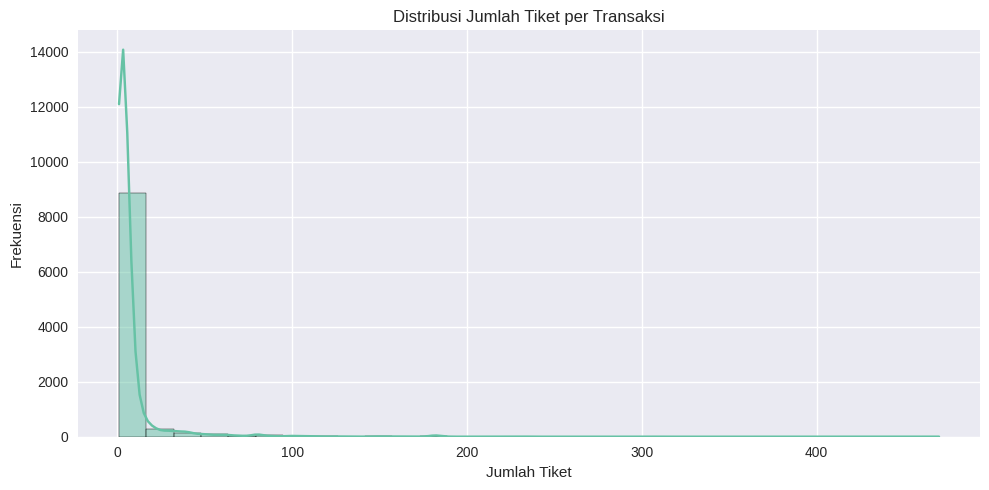

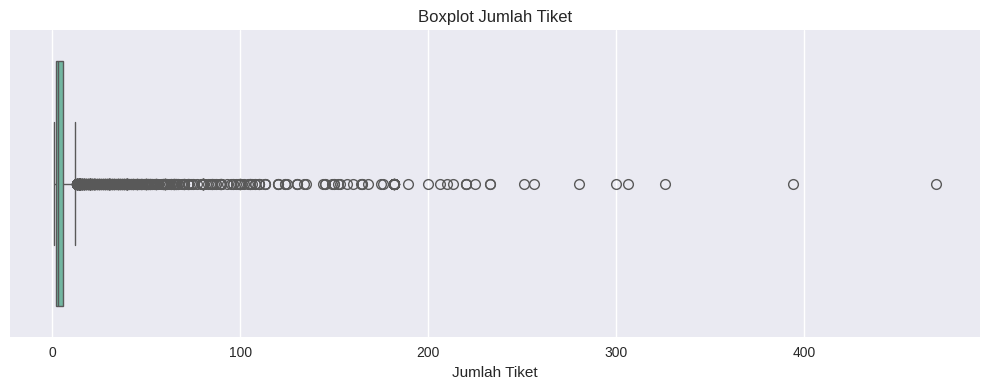

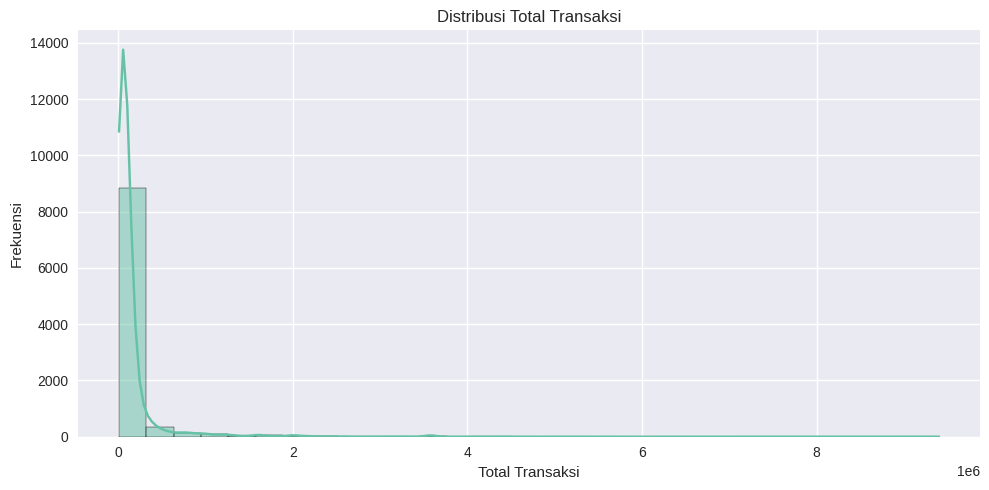

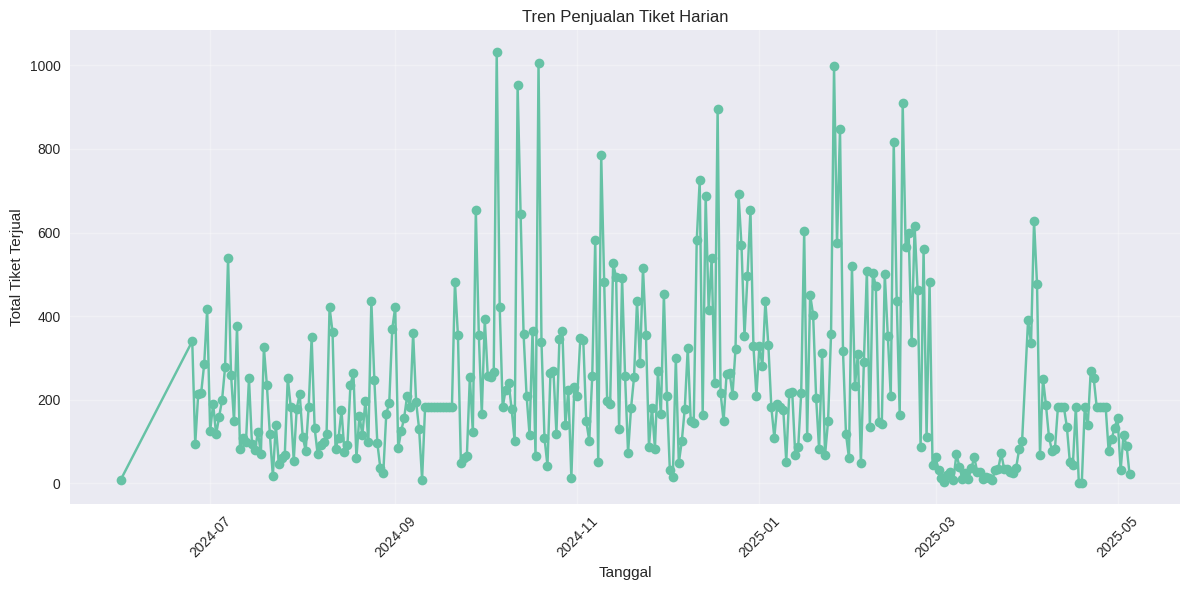

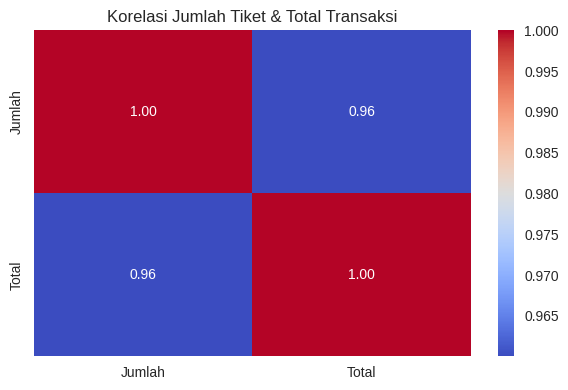


=== INSIGHT EDA ===
Skewness jumlah tiket : 8.54
75% transaksi membeli ≤ 6 tiket


In [ ]:
#setup dan mount drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
drive.mount('/content/drive')

#konfigurasi path dan visualisasi
file_path = '/content/drive/MyDrive/Clustering_TA/penjualan_tiket_raw.xlsx'

if not os.path.exists(file_path):
    raise FileNotFoundError(
        "File tidak ditemukan"
    )

plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

#load dataset dan cek data awal
df = pd.read_excel(file_path)

print("=== INFORMASI DATASET ===")
df.info()

print("\n=== 5 DATA TERATAS ===")
display(df.head())

print(f"\nJumlah baris : {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

print("\n=== MISSING VALUES ===")
print(df.isna().sum())

print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe())

#analisis data
#distribusi jumlah tiket
plt.figure(figsize=(10, 5))
sns.histplot(df['Jumlah'], bins=30, kde=True)
plt.title('Distribusi Jumlah Tiket per Transaksi')
plt.xlabel('Jumlah Tiket')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

#boxplot jumlah tiket (deteksi outlier)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Jumlah'])
plt.title('Boxplot Jumlah Tiket')
plt.xlabel('Jumlah Tiket')
plt.tight_layout()
plt.show()

#distribusi total transaksi
plt.figure(figsize=(10, 5))
sns.histplot(df['Total'], bins=30, kde=True)
plt.title('Distribusi Total Transaksi')
plt.xlabel('Total Transaksi')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

#analisis berdasarkan waktu
df['Tanggal'] = pd.to_datetime(
    df['Tanggal'],
    dayfirst=True,
    errors='coerce'
)

daily_sales = (
    df
    .groupby(df['Tanggal'].dt.date)['Jumlah']
    .sum()
)

plt.figure(figsize=(12, 6))
daily_sales.plot(marker='o')
plt.title('Tren Penjualan Tiket Harian')
plt.xlabel('Tanggal')
plt.ylabel('Total Tiket Terjual')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#analisis hubungan antar variabel
numeric_df = df[['Jumlah', 'Total']].dropna()

plt.figure(figsize=(6, 4))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Korelasi Jumlah Tiket & Total Transaksi')
plt.tight_layout()
plt.show()

#insight statistik dan interpretasi data
skewness_jumlah = df['Jumlah'].skew()
q75 = df['Jumlah'].quantile(0.75)

print("\n=== INSIGHT EDA ===")
print(f"Skewness jumlah tiket : {skewness_jumlah:.2f}")
print(f"75% transaksi membeli ≤ {int(q75)} tiket")



preprocessing dan feature engineering

In [ ]:
#import dan setup
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Clustering_TA")
RAW_PATH = BASE_DIR / "penjualan_tiket_raw.xlsx"
PROCESSED_PATH = BASE_DIR / "penjualan_tiket_clean.csv"

print("RAW_PATH      :", RAW_PATH)
print("PROCESSED_PATH:", PROCESSED_PATH)

if not RAW_PATH.exists():
    raise FileNotFoundError("File tidak ditemukan")

#load data
df = pd.read_excel(RAW_PATH)

print("\n=== DATA AWAL ===")
display(df.head())

#preprocessing
#standarisasi nama kolom
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

#konversi kolom tanggal
df['tanggal'] = pd.to_datetime(
    df['tanggal'],
    dayfirst=True,
    errors='coerce'
)

#memastikan kolom numerik
df['jumlah'] = pd.to_numeric(df['jumlah'], errors='coerce')
df['total'] = pd.to_numeric(df['total'], errors='coerce')

#cek missing value setelah konversi
print("\n=== MISSING VALUES SETELAH KONVERSI ===")
print(df.isnull().sum())

#drop data tidak falid
df = df.dropna().reset_index(drop=True)

#feature engineering
#fitur waktu
df['tahun'] = df['tanggal'].dt.year
df['bulan'] = df['tanggal'].dt.month
df['nama_bulan'] = df['tanggal'].dt.month_name()
df['hari'] = df['tanggal'].dt.day
df['hari_dalam_minggu'] = df['tanggal'].dt.day_name()
df['jam'] = df['tanggal'].dt.hour

#weekend vs weekdays
df['is_weekend'] = df['hari_dalam_minggu'].isin(
    ['Saturday', 'Sunday']
).astype(int)

#harga tiket, menghindari harga 0
df['harga_per_tiket'] = np.where(
    df['jumlah'] > 0,
    df['total'] / df['jumlah'],
    np.nan
)

#label volume penjualan
df['volume_penjualan'] = pd.cut(
    df['jumlah'],
    bins=[0, 2, 5, 10, 50, np.inf],
    labels=[
        'Sangat Rendah',
        'Rendah',
        'Sedang',
        'Tinggi',
        'Sangat Tinggi'
    ]
)

#validasi data akhir
print("\n=== DATA SETELAH PREPROCESSING ===")
display(df.head())
print("\n=== INFO DATA ===")
df.info()

#simpan data setelah preprocessing
df.to_csv(PROCESSED_PATH, index=False)
print(f"\n Data disimpan di:\n{PROCESSED_PATH}")


RAW_PATH      : /content/drive/MyDrive/Clustering_TA/penjualan_tiket_raw.xlsx
PROCESSED_PATH: /content/drive/MyDrive/Clustering_TA/penjualan_tiket_clean.csv

=== DATA AWAL ===


,No,Pembelian,Kategori,Tanggal,Jumlah,Total
0,1,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 11:15:00,13,325000
1,2,TIKET MANCANEGARA,Mancanegara,05-05-2025 10:28:00,1,20000
2,3,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 10:00:00,1,25000
3,4,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,05-05-2025 09:57:00,7,175000
4,5,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,04-05-2025 11:21:00,4,100000



=== MISSING VALUES SETELAH KONVERSI ===
no           0
pembelian    0
kategori     0
tanggal      0
jumlah       0
total        0
dtype: int64

=== DATA SETELAH PREPROCESSING ===


,no,pembelian,kategori,tanggal,jumlah,total,tahun,bulan,nama_bulan,hari,hari_dalam_minggu,jam,is_weekend,harga_per_tiket,volume_penjualan
0,1,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-05 11:15:00,13,325000,2025,5,May,5,Monday,11,0,25000.0,Tinggi
1,2,TIKET MANCANEGARA,Mancanegara,2025-05-05 10:28:00,1,20000,2025,5,May,5,Monday,10,0,20000.0,Sangat Rendah
2,3,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-05 10:00:00,1,25000,2025,5,May,5,Monday,10,0,25000.0,Sangat Rendah
3,4,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-05 09:57:00,7,175000,2025,5,May,5,Monday,9,0,25000.0,Sedang
4,5,"TIKET TERUSAN II (AREA, MUSEUM PUSAKA & DALEM ...",TERUSAN,2025-05-04 11:21:00,4,100000,2025,5,May,4,Sunday,11,1,25000.0,Rendah



=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9579 entries, 0 to 9578
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   no                 9579 non-null   int64         
 1   pembelian          9579 non-null   object        
 2   kategori           9579 non-null   object        
 3   tanggal            9579 non-null   datetime64[ns]
 4   jumlah             9579 non-null   int64         
 5   total              9579 non-null   int64         
 6   tahun              9579 non-null   int32         
 7   bulan              9579 non-null   int32         
 8   nama_bulan         9579 non-null   object        
 9   hari               9579 non-null   int32         
 10  hari_dalam_minggu  9579 non-null   object        
 11  jam                9579 non-null   int32         
 12  is_weekend         9579 non-null   int64         
 13  harga_per_tiket    9579 non-null   float64  

Pembuatan Profil Awal (Profiling Summary)

In [ ]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("/content/drive/MyDrive/Clustering_TA/penjualan_tiket_clustered.csv")

df = pd.read_csv(DATA_PATH)

features = [
    'jumlah',
    'total',
    'harga_per_tiket',
    'is_weekend',
    'jam'
]

cluster_summary = (
    df
    .groupby('cluster')[features]
    .mean()
    .round(2)
)

print("=== RINGKASAN KARAKTERISTIK CLUSTER ===")
display(cluster_summary)


=== RINGKASAN KARAKTERISTIK CLUSTER ===


,jumlah,total,harga_per_tiket,is_weekend,jam
cluster,,,,,
0,5.48,112483.52,20756.59,0.44,12.41
1,125.85,2476842.86,20526.30,0.33,10.99


HIERARCHICAL + HPO



=== INFO DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9579 entries, 0 to 9578
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   no                 9579 non-null   int64  
 1   pembelian          9579 non-null   object 
 2   kategori           9579 non-null   object 
 3   tanggal            9579 non-null   object 
 4   jumlah             9579 non-null   int64  
 5   total              9579 non-null   int64  
 6   tahun              9579 non-null   int64  
 7   bulan              9579 non-null   int64  
 8   nama_bulan         9579 non-null   object 
 9   hari               9579 non-null   int64  
 10  hari_dalam_minggu  9579 non-null   object 
 11  jam                9579 non-null   int64  
 12  is_weekend         9579 non-null   int64  
 13  harga_per_tiket    9579 non-null   float64
 14  volume_penjualan   9579 non-null   object 
dtypes: float64(1), int64(8), object(6)
memory usage: 1.1+

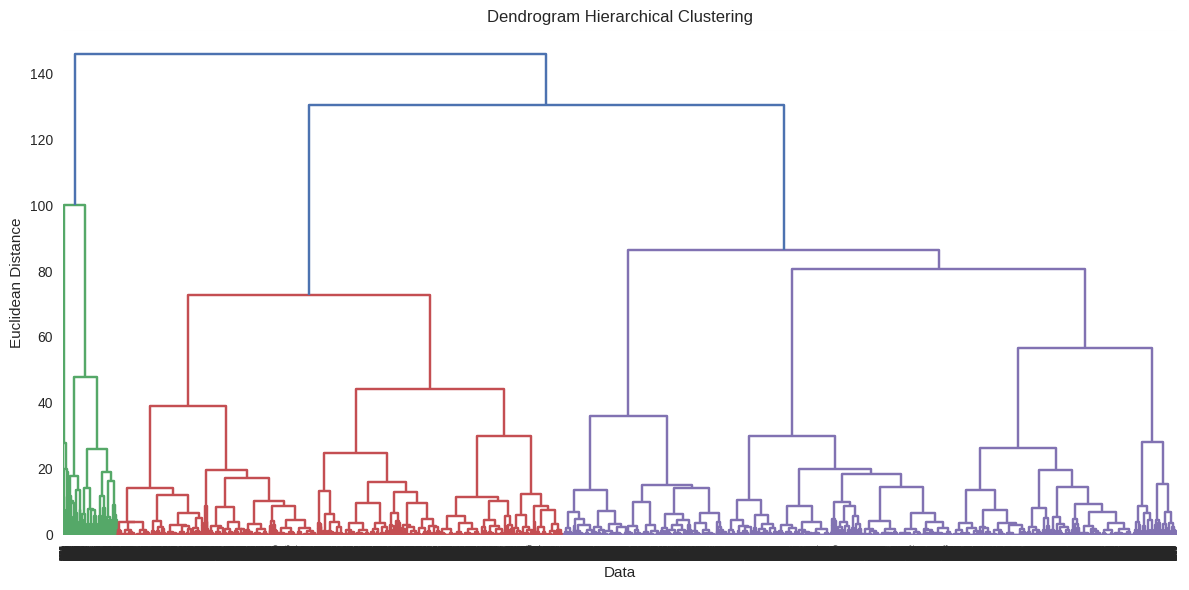


=== HYPERPARAMETER OPTIMIZATION ===
Cluster=2 | Linkage=ward | Silhouette=0.5641
Cluster=2 | Linkage=complete | Silhouette=0.8180
Cluster=2 | Linkage=average | Silhouette=0.9189
Cluster=2 | Linkage=single | Silhouette=0.9189
Cluster=3 | Linkage=ward | Silhouette=0.3244
Cluster=3 | Linkage=complete | Silhouette=0.8130
Cluster=3 | Linkage=average | Silhouette=0.7998
Cluster=3 | Linkage=single | Silhouette=0.8755
Cluster=4 | Linkage=ward | Silhouette=0.3326
Cluster=4 | Linkage=complete | Silhouette=0.8034
Cluster=4 | Linkage=average | Silhouette=0.7902
Cluster=4 | Linkage=single | Silhouette=0.8756
Cluster=5 | Linkage=ward | Silhouette=0.3176
Cluster=5 | Linkage=complete | Silhouette=0.6420
Cluster=5 | Linkage=average | Silhouette=0.7901
Cluster=5 | Linkage=single | Silhouette=0.8733
Cluster=6 | Linkage=ward | Silhouette=0.3150
Cluster=6 | Linkage=complete | Silhouette=0.6420
Cluster=6 | Linkage=average | Silhouette=0.7595
Cluster=6 | Linkage=single | Silhouette=0.8495
Cluster=7 | Linkag

,n_clusters,linkage,metric,silhouette_score,davies_bouldin_score,calinski_harabasz_score
3,2,single,euclidean,0.918860,0.056502,224.378921
2,2,average,euclidean,0.918860,0.056502,224.378921
11,4,single,euclidean,0.875590,0.076607,149.114596
7,3,single,euclidean,0.875529,0.076204,162.009598
15,5,single,euclidean,0.873288,0.078853,137.183382
19,6,single,euclidean,0.849524,0.085806,124.170291
27,8,single,euclidean,0.834598,0.222526,117.874174
23,7,single,euclidean,0.834200,0.091199,113.588949
1,2,complete,euclidean,0.817970,0.376427,2555.555302
5,3,complete,euclidean,0.812962,0.287989,1339.795504



=== PARAMETER TERBAIK ===
Jumlah Cluster : 2
Linkage         : single
Metric          : euclidean
Silhouette      : 0.9189
Davies Bouldin  : 0.0565
Calinski Harabasz : 224.38

=== DISTRIBUSI CLUSTER ===
cluster_hierarchical
0    9578
1       1
Name: count, dtype: int64

=== RATA-RATA FITUR PER CLUSTER ===


,jumlah,total,harga_per_tiket,is_weekend,jam
cluster_hierarchical,,,,,
0,7.63,154713.14,20752.46,0.44,12.39
1,470.00,9400000.00,20000.00,0.00,12.00


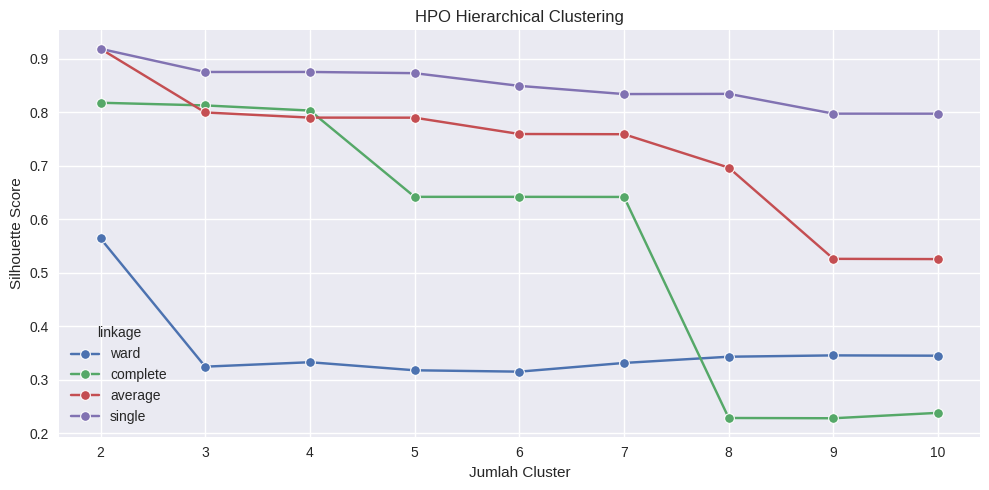

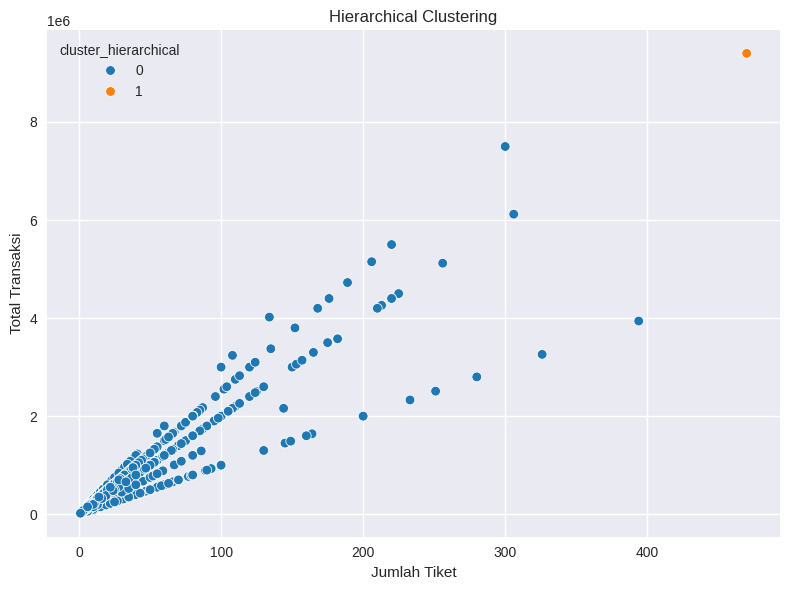


Hasil clustering disimpan di:
/content/drive/MyDrive/Clustering_TA/penjualan_tiket_hierarchical.csv

Hasil HPO disimpan di:
/content/drive/MyDrive/Clustering_TA/hasil_hpo_hierarchical.csv

Total waktu eksekusi: 180.14 detik


In [ ]:
# ======================================================
# IMPORT DAN SETUP
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
import time

from pathlib import Path

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

plt.style.use("seaborn-v0_8")

# ======================================================
# PATH
# ======================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/Clustering_TA"
)

DATA_PATH = (
    BASE_DIR /
    "penjualan_tiket_clean.csv"
)

OUTPUT_PATH = (
    BASE_DIR /
    "penjualan_tiket_hierarchical.csv"
)

HPO_RESULT_PATH = (
    BASE_DIR /
    "hasil_hpo_hierarchical.csv"
)

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_csv(DATA_PATH)

print("\n=== INFO DATA ===")

df.info()

# ======================================================
# SELEKSI FITUR
# ======================================================

features = [
    "jumlah",
    "total",
    "harga_per_tiket",
    "is_weekend",
    "jam"
]

X = df[features].copy()

# ======================================================
# HANDLE MISSING VALUE
# ======================================================

X = (
    X
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

df = df.loc[X.index].reset_index(drop=True)

X = X.reset_index(drop=True)

# ======================================================
# SCALING DATA
# ======================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nShape Data :", X_scaled.shape)

# ======================================================
# DENDROGRAM
# ======================================================

print("\n=== MEMBUAT DENDROGRAM ===")

plt.figure(figsize=(12, 6))

dendrogram = sch.dendrogram(
    sch.linkage(
        X_scaled,
        method='ward'
    )
)

plt.title(
    'Dendrogram Hierarchical Clustering'
)

plt.xlabel('Data')

plt.ylabel('Euclidean Distance')

plt.tight_layout()

plt.show()

# ======================================================
# HPO HIERARCHICAL CLUSTERING
# ======================================================

print(
    "\n=== HYPERPARAMETER "
    "OPTIMIZATION ==="
)

start_time = time.time()

# ======================================================
# PARAMETER HPO
# ======================================================

cluster_range = range(2, 11)

linkage_methods = [
    'ward',
    'complete',
    'average',
    'single'
]

# ======================================================
# MENYIMPAN HASIL
# ======================================================

results = []

# ======================================================
# LOOPING HPO
# ======================================================

for n_cluster in cluster_range:

    for linkage_method in linkage_methods:

        try:

            # ======================================================
            # VALIDASI LINKAGE
            # ======================================================

            if linkage_method == 'ward':

                metric = 'euclidean'

            else:

                metric = 'euclidean'

            # ======================================================
            # TRAIN MODEL
            # ======================================================

            model = AgglomerativeClustering(
                n_clusters=n_cluster,
                linkage=linkage_method,
                metric=metric
            )

            labels = model.fit_predict(
                X_scaled
            )

            # ======================================================
            # EVALUASI
            # ======================================================

            silhouette = silhouette_score(
                X_scaled,
                labels
            )

            davies = davies_bouldin_score(
                X_scaled,
                labels
            )

            calinski = (
                calinski_harabasz_score(
                    X_scaled,
                    labels
                )
            )

            # ======================================================
            # SIMPAN HASIL
            # ======================================================

            results.append({

                "n_clusters":
                    n_cluster,

                "linkage":
                    linkage_method,

                "metric":
                    metric,

                "silhouette_score":
                    silhouette,

                "davies_bouldin_score":
                    davies,

                "calinski_harabasz_score":
                    calinski
            })

            print(
                f"Cluster={n_cluster} | "
                f"Linkage={linkage_method} | "
                f"Silhouette={silhouette:.4f}"
            )

        except Exception as e:

            print(
                f"ERROR | "
                f"Cluster={n_cluster} | "
                f"Linkage={linkage_method}"
            )

            print(e)

# ======================================================
# HASIL HPO
# ======================================================

hpo_results = pd.DataFrame(results)

print("\nJumlah kombinasi diuji :")

print(len(hpo_results))

# ======================================================
# SORT HASIL TERBAIK
# ======================================================

best_results = (
    hpo_results
    .sort_values(
        by="silhouette_score",
        ascending=False
    )
)

print("\n=== TOP 10 HASIL TERBAIK ===")

display(best_results.head(10))

# ======================================================
# PARAMETER TERBAIK
# ======================================================

best_params = best_results.iloc[0]

print("\n=== PARAMETER TERBAIK ===")

print(
    f"Jumlah Cluster : "
    f"{int(best_params['n_clusters'])}"
)

print(
    f"Linkage         : "
    f"{best_params['linkage']}"
)

print(
    f"Metric          : "
    f"{best_params['metric']}"
)

print(
    f"Silhouette      : "
    f"{best_params['silhouette_score']:.4f}"
)

print(
    f"Davies Bouldin  : "
    f"{best_params['davies_bouldin_score']:.4f}"
)

print(
    f"Calinski Harabasz : "
    f"{best_params['calinski_harabasz_score']:.2f}"
)

# ======================================================
# TRAIN FINAL MODEL
# ======================================================

best_model = AgglomerativeClustering(
    n_clusters=int(
        best_params['n_clusters']
    ),
    linkage=best_params['linkage'],
    metric=best_params['metric']
)

final_labels = best_model.fit_predict(
    X_scaled
)

# ======================================================
# TAMBAHKAN CLUSTER
# ======================================================

df['cluster_hierarchical'] = (
    final_labels
)

# ======================================================
# DISTRIBUSI CLUSTER
# ======================================================

print("\n=== DISTRIBUSI CLUSTER ===")

print(
    df['cluster_hierarchical']
    .value_counts()
)

# ======================================================
# ANALISIS CLUSTER
# ======================================================

cluster_summary = (
    df
    .groupby('cluster_hierarchical')
    [features]
    .mean()
    .round(2)
)

print(
    "\n=== RATA-RATA "
    "FITUR PER CLUSTER ==="
)

display(cluster_summary)

# ======================================================
# VISUALISASI HPO
# ======================================================

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hpo_results,
    x='n_clusters',
    y='silhouette_score',
    hue='linkage',
    marker='o'
)

plt.title(
    'HPO Hierarchical Clustering'
)

plt.xlabel('Jumlah Cluster')

plt.ylabel('Silhouette Score')

plt.tight_layout()

plt.show()

# ======================================================
# VISUALISASI CLUSTER
# ======================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='jumlah',
    y='total',
    hue='cluster_hierarchical',
    data=df,
    palette='tab10'
)

plt.title(
    'Hierarchical Clustering'
)

plt.xlabel('Jumlah Tiket')

plt.ylabel('Total Transaksi')

plt.tight_layout()

plt.show()

# ======================================================
# SIMPAN HASIL
# ======================================================

df.to_csv(
    OUTPUT_PATH,
    index=False
)

hpo_results.to_csv(
    HPO_RESULT_PATH,
    index=False
)

print(
    f"\nHasil clustering disimpan di:\n"
    f"{OUTPUT_PATH}"
)

print(
    f"\nHasil HPO disimpan di:\n"
    f"{HPO_RESULT_PATH}"
)

# ======================================================
# TOTAL WAKTU EKSEKUSI
# ======================================================

end_time = time.time()

execution_time = (
    end_time - start_time
)

print(
    f"\nTotal waktu eksekusi: "
    f"{execution_time:.2f} detik"
)

Evaluasi Performa Multi-Metrik


EVALUASI HIERARCHICAL CLUSTERING

=== PARAMETER TERBAIK ===
Jumlah Cluster : 2
Linkage         : single
Metric          : euclidean

Jumlah Cluster : 2

=== DISTRIBUSI CLUSTER ===
cluster_hierarchical
0    9578
1       1
Name: count, dtype: int64

=== PERSENTASE CLUSTER ===
cluster_hierarchical
0    99.99
1     0.01
Name: proportion, dtype: float64

Silhouette Score : 0.9189
Interpretasi : Struktur cluster sangat kuat

Davies-Bouldin Index : 0.0565
Semakin kecil DBI maka cluster semakin baik

Calinski-Harabasz Index : 224.38
Semakin besar CHI maka pemisahan cluster semakin baik

=== RATA-RATA FITUR PER CLUSTER ===


,jumlah,total,harga_per_tiket,is_weekend,jam
cluster_hierarchical,,,,,
0,7.63,154713.14,20752.46,0.44,12.39
1,470.00,9400000.00,20000.00,0.00,12.00


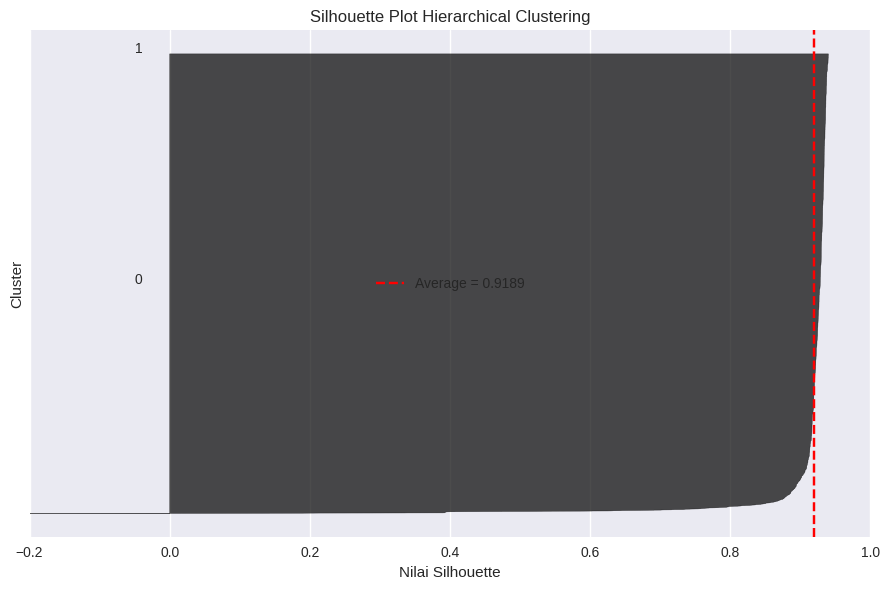

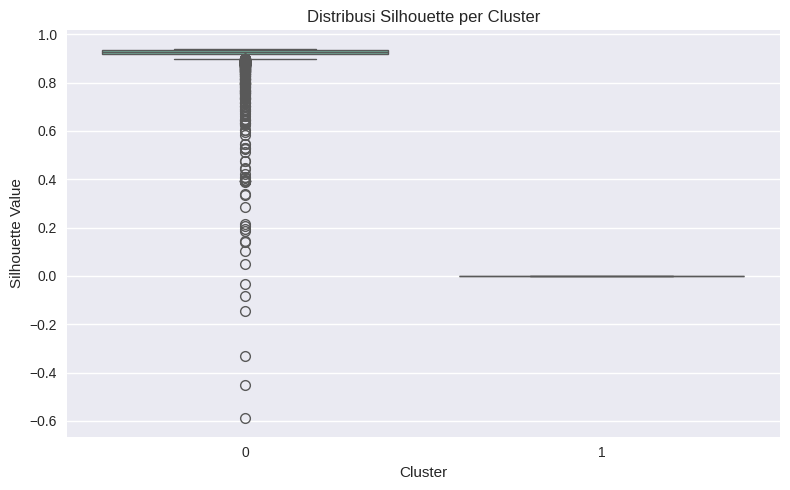


=== RATA-RATA SILHOUETTE PER CLUSTER ===
cluster
0    0.919
1    0.000
Name: silhouette_value, dtype: float64


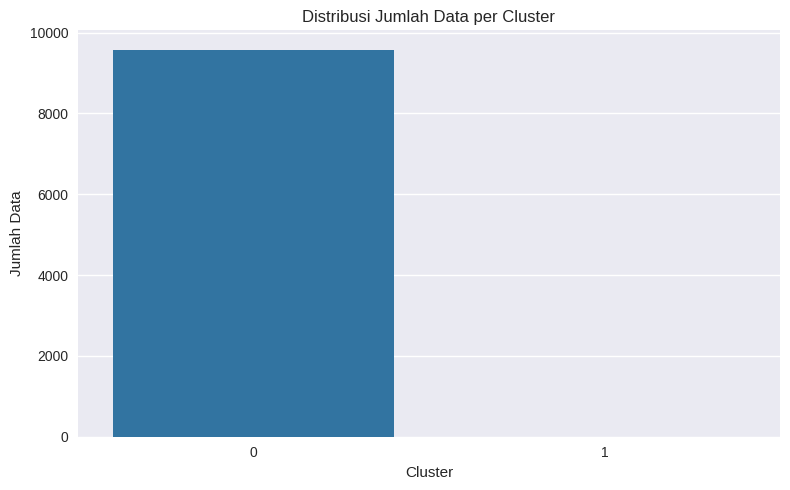

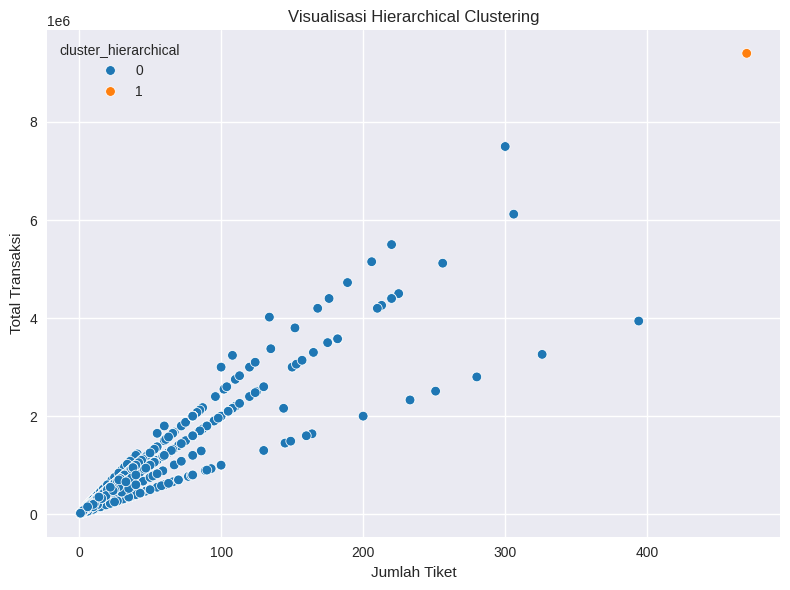


=== EVALUASI SELESAI ===


In [ ]:
# ======================================================
# EVALUASI MODEL HIERARCHICAL CLUSTERING
# ======================================================

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

import matplotlib.cm as cm
import seaborn as sns

print("\n===================================")
print("EVALUASI HIERARCHICAL CLUSTERING")
print("===================================")

# ======================================================
# LABEL CLUSTER
# ======================================================

labels = df["cluster_hierarchical"]

# ======================================================
# PARAMETER TERBAIK
# ======================================================

print("\n=== PARAMETER TERBAIK ===")

print(
    f"Jumlah Cluster : "
    f"{int(best_params['n_clusters'])}"
)

print(
    f"Linkage         : "
    f"{best_params['linkage']}"
)

print(
    f"Metric          : "
    f"{best_params['metric']}"
)

# ======================================================
# INFORMASI CLUSTER
# ======================================================

unique_clusters = np.unique(labels)

n_clusters = len(unique_clusters)

print(f"\nJumlah Cluster : {n_clusters}")

# ======================================================
# DISTRIBUSI CLUSTER
# ======================================================

cluster_distribution = (
    df["cluster_hierarchical"]
    .value_counts()
    .sort_index()
)

print("\n=== DISTRIBUSI CLUSTER ===")

print(cluster_distribution)

# ======================================================
# PERSENTASE CLUSTER
# ======================================================

cluster_percentage = (
    df["cluster_hierarchical"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\n=== PERSENTASE CLUSTER ===")

print(cluster_percentage.round(2))

# ======================================================
# SILHOUETTE SCORE
# ======================================================

sil_score = silhouette_score(
    X_scaled,
    labels
)

print(
    f"\nSilhouette Score : "
    f"{sil_score:.4f}"
)

# ======================================================
# INTERPRETASI SILHOUETTE
# ======================================================

if sil_score >= 0.71:

    interpretasi = (
        "Struktur cluster sangat kuat"
    )

elif sil_score >= 0.51:

    interpretasi = (
        "Struktur cluster baik"
    )

elif sil_score >= 0.26:

    interpretasi = (
        "Struktur cluster cukup"
    )

else:

    interpretasi = (
        "Struktur cluster lemah"
    )

print(
    "Interpretasi :",
    interpretasi
)

# ======================================================
# DAVIES BOULDIN INDEX
# ======================================================

db_index = davies_bouldin_score(
    X_scaled,
    labels
)

print(
    f"\nDavies-Bouldin Index : "
    f"{db_index:.4f}"
)

print(
    "Semakin kecil DBI "
    "maka cluster semakin baik"
)

# ======================================================
# CALINSKI HARABASZ INDEX
# ======================================================

ch_index = calinski_harabasz_score(
    X_scaled,
    labels
)

print(
    f"\nCalinski-Harabasz Index : "
    f"{ch_index:.2f}"
)

print(
    "Semakin besar CHI "
    "maka pemisahan cluster semakin baik"
)

# ======================================================
# RATA-RATA FITUR CLUSTER
# ======================================================

cluster_summary = (
    df
    .groupby("cluster_hierarchical")[features]
    .mean()
    .round(2)
)

print(
    "\n=== RATA-RATA FITUR "
    "PER CLUSTER ==="
)

display(cluster_summary)

# ======================================================
# SILHOUETTE SAMPLE
# ======================================================

sample_silhouette_values = (
    silhouette_samples(
        X_scaled,
        labels
    )
)

# ======================================================
# SILHOUETTE PLOT
# ======================================================

fig, ax = plt.subplots(
    figsize=(9, 6)
)

y_lower = 10

for i in unique_clusters:

    ith_cluster_silhouette_values = (
        sample_silhouette_values[
            labels == i
        ]
    )

    ith_cluster_silhouette_values.sort()

    size_cluster_i = (
        ith_cluster_silhouette_values.shape[0]
    )

    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(
        float(i) / n_clusters
    )

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7
    )

    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster_i,
        str(i)
    )

    y_lower = y_upper + 10

# ======================================================
# GARIS RATA-RATA SILHOUETTE
# ======================================================

ax.axvline(
    x=sil_score,
    color="red",
    linestyle="--",
    label=f"Average = {sil_score:.4f}"
)

ax.set_title(
    "Silhouette Plot "
    "Hierarchical Clustering"
)

ax.set_xlabel(
    "Nilai Silhouette"
)

ax.set_ylabel(
    "Cluster"
)

ax.set_yticks([])

ax.set_xlim([-0.2, 1])

ax.legend()

plt.tight_layout()

plt.show()

# ======================================================
# DISTRIBUSI SILHOUETTE
# ======================================================

silhouette_df = pd.DataFrame({

    "cluster":
        labels,

    "silhouette_value":
        sample_silhouette_values
})

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="cluster",
    y="silhouette_value",
    hue="cluster",
    data=silhouette_df,
    palette="Set2",
    legend=False
)

plt.title(
    "Distribusi Silhouette "
    "per Cluster"
)

plt.xlabel("Cluster")

plt.ylabel(
    "Silhouette Value"
)

plt.tight_layout()

plt.show()

# ======================================================
# RATA-RATA SILHOUETTE
# ======================================================

cluster_silhouette = (
    silhouette_df
    .groupby("cluster")[
        "silhouette_value"
    ]
    .mean()
)

print(
    "\n=== RATA-RATA "
    "SILHOUETTE PER CLUSTER ==="
)

print(
    cluster_silhouette.round(4)
)

# ======================================================
# VISUALISASI DISTRIBUSI CLUSTER
# ======================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    x="cluster_hierarchical",
    data=df,
    hue="cluster_hierarchical",
    palette="tab10",
    legend=False
)

plt.title(
    "Distribusi Jumlah Data "
    "per Cluster"
)

plt.xlabel("Cluster")

plt.ylabel("Jumlah Data")

plt.tight_layout()

plt.show()

# ======================================================
# VISUALISASI CLUSTER
# ======================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='jumlah',
    y='total',
    hue='cluster_hierarchical',
    data=df,
    palette='tab10'
)

plt.title(
    'Visualisasi Hierarchical Clustering'
)

plt.xlabel('Jumlah Tiket')

plt.ylabel('Total Transaksi')

plt.tight_layout()

plt.show()

print("\n=== EVALUASI SELESAI ===")

In [ ]:
import joblib
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Clustering_TA")

joblib.dump(best_model, BASE_DIR / 'hierarchical_model.pkl')

['/content/drive/MyDrive/Clustering_TA/hierarchical_model.pkl']